### 1. 感知机的公式原理

实际上感知机是一个二元的分类模型,输出值只有零和一，其核心算法是
：w1x1+w2x2与θ的比较，其中w1，w2，可以认为是权重参数，而θ是判断的标准
当前式大于θ时，可以输出1，反之则为零。

### 2. 简单逻辑电路

- 与门

概念简单，在此略过，类似的概念有与非门和或门。其含义类似于逻辑判断里面的否与或。
可以利用感知机模式实现与门，但此时是由我们自己来确定权重参数和θ，而学习的本质就是让机器来帮我们确定这些参数。
我们要做的就是思考如何构造这个感知机，并将数据传给计算机


### 3. 感知机的实现

下面是最简单的感知机

In [7]:
def amd(x1,x2):
    w1,w2,theta=0.5,0.5,0.7
    temp=w1*x1+w2*x2
    if temp>theta:
        return 1
    else:
        return 0
    #这里的权重参数是人工取的
print(amd(0,0))
print(amd(1,1))
print(amd(0,1))
print(amd(1,0))

0
1
0
0


以上是使用python最简单的感知机实现与门，接下来将使用numpy实现

In [8]:
import numpy as np
x=np.array([0,1])
w=np.array([0.5,0.5])
b=-0.7
print(w*x)
print(np.sum(w*x))
print(np.sum(w*x)+b)
if(np.sum(w*x)>0):
    print(1)
else:
    print(0)


[0.  0.5]
0.5
-0.19999999999999996
1


与非门和或门的构造同理，唯一不一样的是更换权重和偏置(即θ)的值

### 4. 感知机的局限性

异或门！这种问题的实现依靠感知机是不能完成的，实际上是常见的当a发生且b不发生的问题。要搞明白这件事情很简单，我们可以利用平面直角坐标系形象的解决，图像的生成借助的是mat。

D:\Users\Yu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Users\Yu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Users\Yu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Users\Yu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Users\Yu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas

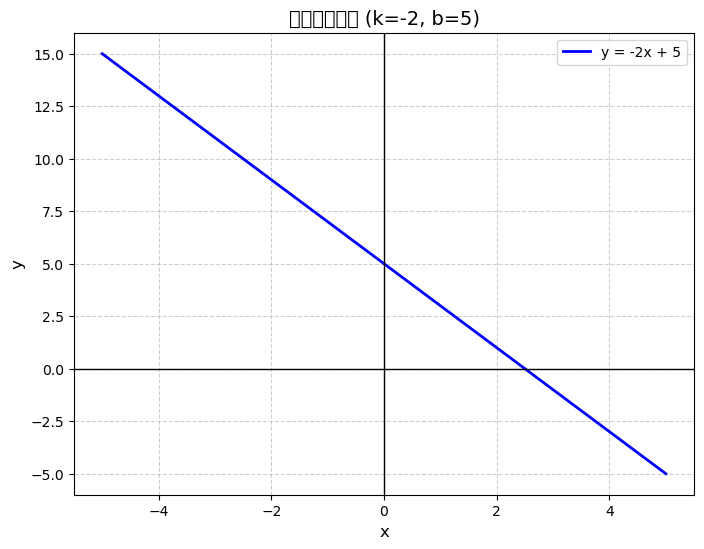

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 设置函数参数：k小于0，截距大于0
k = -2
b = 5

# 2. 定义自变量x的取值范围（例如从 -5 到 5）
x = np.linspace(-5, 5, 100)

# 3. 计算对应的函数值 y = kx + b
y = k * x + b

# 4. 绘制图像
plt.figure(figsize=(8, 6))
plt.plot(x, y, color='blue', linewidth=2, label=f'y = {k}x + {b}')

# 5. 添加辅助线（x轴和y轴）
plt.axhline(0, color='black', linewidth=1) # x轴
plt.axvline(0, color='black', linewidth=1) # y轴

# 6. 设置图表信息
plt.title(f'一次函数图像 (k={k}, b={b})', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()  # 显示图例
plt.grid(True, linestyle='--', alpha=0.6) # 显示网格
plt.show()

我们注意到，当我们将x1,x2分别作为横纵坐标时，与坐标轴有两个交点，分别作垂线又交于一点，算上原点一共四个点，
感知机所做的就是找到这么一条线，能够恰当的分开这些点

而我们的异或门问题中，便是要找一条直线，将四个点分为两组，一组是坐标轴交点，另一组为剩余两点，显然，不存在这样的直线

4.2 线性与非线性

在上面的问题中我们知道，直线不可能完成这样的，任务，但是曲线很轻松完成。但是感知机无法表示曲线，这就是其局限性，这里引申出线性空间与非线性空间，顾名思义，由直线分割成的空间称为线性空间，由曲线分割的叫做非线性空间。

### 5.多层感知机

由上述问题我们知道，单层的感知机无法胜任这样的任务，但是我们是否可以应该多层感知机，用与门，非与门，或门的堆积来实现异或门，答案是肯定的。

In [12]:
def AND(x1,x2):
    x=np.array([x1,x2])
    w=np.array([0.5,0.5])
    b=-0.7
    temp=np.sum(w*x)+b
    if temp>0:
        return 1
    else:
        return 0#与门的代码
def NAND(x1,x2):
    x=np.array([x1,x2])
    w=np.array([-0.5,-0.5])#只需使权重和与门的相反
    b=0.7
    temp=np.sum(w*x)+b
    if temp>0:
        return 1
    else:
        return 0#这是非与门的实现
def OR(x1,x2):
    x=np.array([x1,x2])
    w=np.array([0.5,0.5])
    b=-0.2
    temp=np.sum(w*x)+b
    if temp>0:
        return 1
    else:
        return 0#或门
def xor(x1,x2):
    s1=NAND(x1,x2)
    s2=OR(x1,x2)
    y=AND(s1,s2)
    print(y)
    return
xor(0,0)
xor(0,1)
xor(1,1)
xor(1,0)

0
1
0
1


这样我们就使用多层感知机解决了问题，理论上感知机是很强力的工具，因为已经证明两层感知机就能构建计算机，不过合适权重的设置非常困难，所以就不多赘述